In [1]:
import random
from collections import deque
from pathlib import Path

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output
from gymnasium import ObservationWrapper
from gymnasium.spaces import Box
from gymnasium.wrappers import FrameStackObservation
from gymnasium.wrappers import AtariPreprocessing
import cv2

In [2]:
class ReplayBuffer:
    def __init__(self, capacity, device):
        self.buffer = deque(maxlen=capacity)
        self.device = device

    def add(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)

        obs = torch.tensor(np.array(obs), dtype=torch.float32, device=self.device) / 255.0
        next_obs = torch.tensor(np.array(next_obs), dtype=torch.float32, device=self.device) / 255.0

        actions = torch.tensor(actions, dtype=torch.long, device=self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        dones = torch.tensor(dones, dtype=torch.float32, device=self.device)

        return obs, actions, rewards, next_obs, dones

    def __len__(self):
        return len(self.buffer)

In [3]:
class DQN(nn.Module):
    def __init__(self, obs_shape, n_actions):
        super().__init__()

        # obs_shape should be (4, 84, 84)
        c, h, w = obs_shape

        self.conv = nn.Sequential(
            nn.Conv2d(c, 32, kernel_size=8, stride=4),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, c, h, w)
            conv_out_size = self.conv(dummy).view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [4]:
class Agent:
    def __init__(self, obs_shape, n_actions, device, gamma=0.99, lr=1e-4):
        self.device = device
        self.n_actions = n_actions
        self.gamma = gamma

        self.q_net = DQN(obs_shape, n_actions).to(device)
        self.target_net = DQN(obs_shape, n_actions).to(device)

        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)

    def select_action(self, obs, epsilon, action_space):
        if random.random() < epsilon:
            return action_space.sample()

        obs_t = torch.tensor(obs, dtype=torch.float32, device=self.device)
        obs_t = obs_t.unsqueeze(0) / 255.0

        with torch.no_grad():
            q_values = self.q_net(obs_t)

        return q_values.argmax(dim=1).item()

    def learn(self, batch):
        obs, actions, rewards, next_obs, dones = batch

        q_values = self.q_net(obs)
        action_q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = self.target_net(next_obs)
            max_next_q_values = next_q_values.max(dim=1).values
            targets = rewards + self.gamma * max_next_q_values * (1 - dones)

        loss = F.mse_loss(action_q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

In [5]:
def make_env(visualize=False, seed=42):
    gym.register_envs(ale_py)

    env = gym.make(
        "ALE/Breakout-v5",
        frameskip=1,
        render_mode="human" if visualize else None,
    )

    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        grayscale_newaxis=False,
        scale_obs=False,
    )
    env = FrameStackObservation(env, stack_size=4)

    obs, info = env.reset(seed=seed)
    return env, obs, info

In [6]:
from collections import Counter


def evaluate(agent, episodes=5, max_steps=5000):
    env, obs, info = make_env(visualize=True)

    scores = []
    

    for episode in range(episodes):
        obs, info = env.reset()
        action_counts = Counter
        # launch ball
        obs, reward, terminated, truncated, info = env.step(1)

        total_reward = 0
        lives = info.get("lives", 0)

        for step in range(max_steps):
            action = agent.select_action(
                obs,
                epsilon=0.05,
                action_space=env.action_space,
            )

            action_counts[action] += 1

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

            done = terminated or truncated
            new_lives = info.get("lives", lives)

            if new_lives < lives and not done:
                obs, fire_reward, terminated, truncated, info = env.step(1)
                total_reward += fire_reward
                done = terminated or truncated

            lives = info.get("lives", new_lives)

            if done:
                break

        scores.append(total_reward)
        print(f"Episode {episode + 1}: {total_reward}")
        print(action_counts)

    print(f"Average reward: {np.mean(scores):.2f}")
    return scores

In [7]:
import numpy as np

def moving_average(values, window=20):
    if len(values) < window:
        return []

    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid"
    )

In [8]:
def plot_training(episode_rewards, losses):

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)

    plt.plot(
        episode_rewards,
        alpha=0.3,
        label="Episode Reward"
    )

    if len(episode_rewards) >= 20:
        plt.plot(
            moving_average(episode_rewards, 20),
            linewidth=2,
            label="20 Episode Moving Average"
        )

    plt.title("Episode Reward")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(losses)
    plt.title("DQN Loss")
    plt.xlabel("Gradient Update")
    plt.ylabel("MSE Loss")

    plt.tight_layout()
    plt.show()

In [9]:
def save_checkpoint(path, agent, epsilon, step, episode, episode_rewards, losses):
    checkpoint = {
        "q_net_state_dict": agent.q_net.state_dict(),
        "optimizer_state_dict": agent.optimizer.state_dict(),
        "epsilon": epsilon,
        "step": step,
        "episode": episode,
        "episode_rewards": episode_rewards,
        "losses": losses,
        "target_net_state_dict": agent.target_net.state_dict()
    }

    torch.save(checkpoint, path)
    print(f"Saved checkpoint to {path}")

In [10]:
def load_checkpoint(path, agent, device):
    checkpoint = torch.load(path, map_location=device)

    agent.q_net.load_state_dict(checkpoint["q_net_state_dict"])
    agent.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    agent.target_net.load_state_dict(checkpoint["target_net_state_dict"])

    print(f"Loaded checkpoint from {path}")
    
    return {
        "epsilon": checkpoint["epsilon"],
        "step": checkpoint["step"],
        "episode": checkpoint["episode"],
        "episode_rewards": checkpoint["episode_rewards"],
        "losses": checkpoint["losses"],
    }

In [12]:
def train(
    agent,
    env,
    replay_buffer,
    num_steps=50_000,
    batch_size=32,
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.999995,
    save_every=5_000,
    checkpoint_path="breakout_dqn_checkpoint.pt",
    start_step=0,
    start_episode=0,
    target_update_every=1000,
    episode_rewards=None,
    losses=None,
    learning_starts=5000
):
    obs, info = env.reset()
    obs, reward, terminated, truncated, info = env.step(1)  # FIRE
    lives = info.get("lives", 0)

    episode_reward = 0
    episode = start_episode
    update_count = 0

    if episode_rewards is None:
        episode_rewards = []

    if losses is None:
        losses = []

    for local_step in range(num_steps):
        global_step = start_step + local_step

        action = agent.select_action(obs, epsilon, env.action_space)

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        new_lives = info.get("lives", lives)

        if new_lives < lives and not done:
            next_obs, fire_reward, terminated, truncated, info = env.step(1)
            reward += fire_reward
            done = terminated or truncated

        lives = info.get("lives", new_lives)

        replay_buffer.add(obs, action, reward, next_obs, done)
        episode_reward += reward

        loss = None

        if len(replay_buffer) >= learning_starts:
            batch = replay_buffer.sample(batch_size)
            loss = agent.learn(batch)
            losses.append(loss)
            update_count += 1

            if update_count % target_update_every == 0:
                agent.update_target_network

        if done:
            episode_rewards.append(episode_reward)
            episode += 1
            episode_reward = 0

            obs, info = env.reset()
            obs, reward, terminated, truncated, info = env.step(1)
            lives = info.get("lives", 0)
        else:
            obs = next_obs

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if local_step % 500 == 0:
            clear_output(wait=True)
            print(f"Global step: {global_step}")
            print(f"Local step: {local_step}")
            print(f"Episode: {episode}")
            print(f"Gradient updates this run: {update_count}")
            print(f"Epsilon: {epsilon:.3f}")
            print(f"Replay buffer size: {len(replay_buffer)}")

            if loss is not None:
                print(f"Latest loss: {loss:.5f}")

            if episode_rewards:
                print(f"Latest episode reward: {episode_rewards[-1]}")

            plot_training(episode_rewards, losses)

        if global_step > 0 and global_step % save_every == 0:
            save_checkpoint(
                checkpoint_path,
                agent,
                epsilon,
                global_step,
                episode,
                episode_rewards,
                losses,
            )

    final_step = start_step + num_steps

    save_checkpoint(
        checkpoint_path,
        agent,
        epsilon,
        final_step,
        episode,
        episode_rewards,
        losses,
    )

    return agent, epsilon, episode_rewards, losses

In [14]:
visualize = False

env, obs, info = make_env(visualize=visualize, seed=42)

CHECKPOINT_PATH = "breakout_dqn_checkpoint.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"
agent = Agent(obs.shape, env.action_space.n, device)
replay_buffer = ReplayBuffer(capacity=5000, device=device)
epsilon = 1.0
start_step=0
start_episode=0
episode_rewards=[]
losses=[]

In [15]:

if Path(CHECKPOINT_PATH).exists():
    checkpoint = load_checkpoint(
        CHECKPOINT_PATH,
        agent,
        device,
    )

    epsilon = checkpoint["epsilon"]
    start_step=checkpoint["step"]
    start_episode=checkpoint["episode"]
    episode_rewards=checkpoint["episode_rewards"]
    losses=checkpoint["losses"]

    print(f"Resuming from step {checkpoint['step']}")

else:
    print("No checkpoint found. Starting fresh.")

Loaded checkpoint from breakout_dqn_checkpoint.pt
Resuming from step 10000


Global step: 9500
Local step: 4500
Episode: 54
Gradient updates this run: 4501
Epsilon: 0.930
Replay buffer size: 5000
Latest loss: 0.00018
Latest episode reward: 3.0


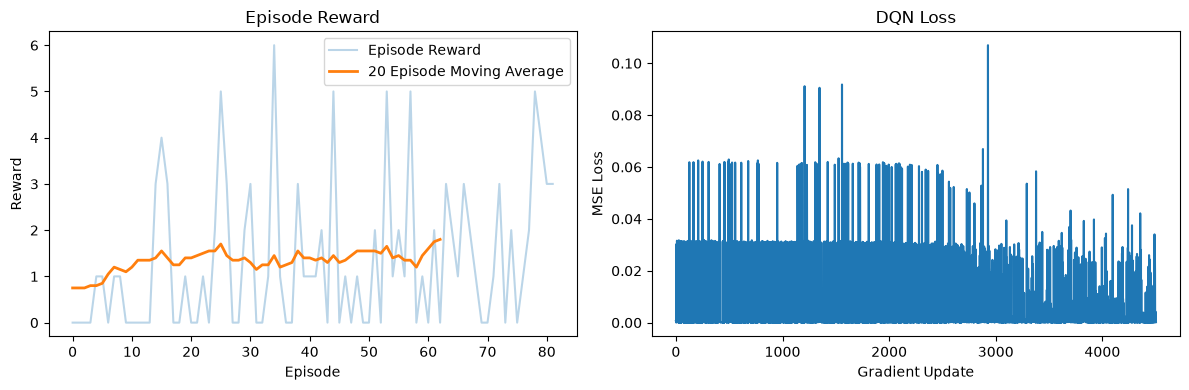

Saved checkpoint to breakout_dqn_checkpoint.pt


In [18]:
agent, epsilon, episode_rewards, losses = train(
    agent,
    env,
    replay_buffer,
    num_steps=5000,
    epsilon=epsilon,
    start_step=start_step,
    start_episode=start_episode,
    episode_rewards=episode_rewards,
    losses=losses,
)

In [20]:
evaluate(agent, episodes=5)

Episode 1: 0.0
Counter({0: 116, np.int64(2): 2, np.int64(1): 1, np.int64(3): 1})
Episode 2: 0.0
Counter({0: 117, np.int64(2): 2, np.int64(1): 1})
Episode 3: 2.0
Counter({0: 179, np.int64(3): 10, 2: 4, np.int64(1): 2})
Episode 4: 1.0
Counter({0: 150, np.int64(2): 7, np.int64(3): 6, np.int64(1): 3})
Episode 5: 0.0
Counter({0: 111, 2: 5, np.int64(3): 4})
Average reward: 0.60


[0.0, 0.0, 2.0, 1.0, 0.0]